# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno 1 : Maximiliano Romano 
- Alumno 2 : Facundo Molina

In [1]:
## TO-DO utiliza esta notebook para documentar, entrenar y probar el modelo.

**LIBRERÍAS**

In [2]:
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.datasets import fetch_lfw_people
import numpy as np
import insightface
from PIL import Image
from dataclasses import dataclass
from typing import List, Dict, Any, Tuple
from facenet_pytorch import InceptionResnetV1
import torch
from torchvision import transforms
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder

c:\Users\maxir\OneDrive\Documents\tp_cv_1\tuia-face-recognition-app\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from facenet_pytorch import InceptionResnetV1

model = InceptionResnetV1(pretrained='vggface2', classify=False).eval()

torch.save(model.state_dict(), "models/inceptionresnetv1_finetuned.pth")

In [4]:
import torch
from facenet_pytorch import InceptionResnetV1

model = InceptionResnetV1(pretrained='vggface2', classify=False).eval()

torch.save(model, "models/inceptionresnetv1_finetuned.pth")

In [5]:
import sys
import os
from pathlib import Path

root_path = Path(os.getcwd()) 
sys.path.append(str(root_path / "src"))

from src.lib.schemas import AlignedFace, EmbeddingRecord, InsertRequest
from src.lib.services.face_service import FaceService

service = FaceService(
    store=None,
    similarity_metric="cosine",
    similarity_threshold=0.6,
    face_size=160,
    model_path="models/inceptionresnetv1_finetuned.pth"   
)

**DATASET**

In [6]:
# DESCARGA DE DATASET LFW, RECORTE DE 20 PRINCIPALES Y GUARDADO EN CARPETA
lfw_people = fetch_lfw_people(min_faces_per_person=40, resize=1.0)

unique, counts = np.unique(lfw_people.target, return_counts=True)

top_20 = unique[np.argsort(counts)[-20:]]

mask = np.isin(lfw_people.target, top_20)
X = lfw_people.images[mask]
y = lfw_people.target[mask]


new_labels = {old: new for new, old in enumerate(top_20)}
y = np.array([new_labels[label] for label in y])

target_names = lfw_people.target_names[top_20]

base_path = Path("data/processed")


for name in target_names:
    person_path = base_path / name.replace(" ", "_")
    person_path.mkdir(parents=True, exist_ok=True)

for i, (img, label_idx) in enumerate(zip(X, y)):

    name = target_names[label_idx].replace(" ", "_")

    img_to_save = (img * 255).astype(np.uint8)

    img_to_save = cv2.cvtColor(img_to_save, cv2.COLOR_GRAY2BGR)

    file_name = f"{name}_{i:04d}.jpg"
    file_path = base_path / name / file_name

    cv2.imwrite(str(file_path), img_to_save)

Shape: (125, 94, 3)


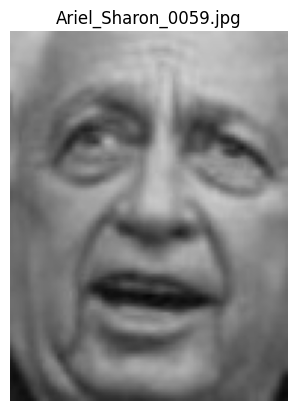

Tipo de boxes: <class 'list'>
Contenido: [(0, 0, 94, 125)]


In [7]:
img_path = next(Path("data/processed/Ariel_Sharon").glob("*.jpg"))
img = cv2.imread(str(img_path))
print(f"Shape: {img.shape}")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(img_path.name)
plt.axis('off')
plt.show()

boxes = service.detect_faces(img)
print(f"Tipo de boxes: {type(boxes)}")
print(f"Contenido: {boxes}")

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo = InceptionResnetV1(pretrained="vggface2").eval().to(device)

# Extraccion embeddings

In [15]:
dataset = Path('src/data/processed')
output_dir = Path("output/post-processed")
output_dir.mkdir(parents=True, exist_ok=True)

pil_faces = {}
embeddings_db = {}

preprocess = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

for folder in dataset.iterdir():
    if not folder.is_dir():
        continue
    persona_name = folder.name

    for img_path in folder.glob('*.jpg'):
        k = f"{persona_name}_{img_path.name}"

        pil_img = Image.open(img_path).convert('RGB')
        face_pil = pil_img.resize((160, 160))

        pil_faces[k] = face_pil
        face_pil.save(output_dir / f"{k}.jpg")

        face_tensor = preprocess(pil_img).unsqueeze(0).to(device)
        with torch.no_grad():
            embedding = modelo(face_tensor).squeeze().cpu().numpy()

        embeddings_db[k] = embedding

print(f"Procesadas: {len(pil_faces)} caras de {len(list(dataset.iterdir()))} personas")

Procesadas: 1867 caras de 19 personas


In [10]:
import json

embeddings_to_save = {k: v.tolist() for k, v in embeddings_db.items()}

with open("src/data/embeddings.json", "w") as f:
    json.dump(embeddings_to_save, f)

print(f"✅ Guardados {len(embeddings_to_save)} embeddings")

✅ Guardados 1867 embeddings


**FINE-TUNING**

In [12]:
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn


all_embeddings = []
all_labels = []

for k, emb in embeddings_db.items():
    persona = "_".join(k.split("_")[:2])  # "Ariel_Sharon"
    all_embeddings.append(emb)
    all_labels.append(persona)

le = LabelEncoder()
y = torch.tensor(le.fit_transform(all_labels), dtype=torch.long)
X = torch.tensor(np.array(all_embeddings), dtype=torch.float32)

print(f"Dataset: {len(X)} imágenes | {len(le.classes_)} clases")
print(f"Clases: {list(le.classes_)}")

Dataset: 1867 imágenes | 19 clases
Clases: ['Ariel_Sharon', 'Arnold_Schwarzenegger', 'Colin_Powell', 'Donald_Rumsfeld', 'George_W', 'Gerhard_Schroeder', 'Gloria_Macapagal', 'Hugo_Chavez', 'Jacques_Chirac', 'Jean_Chretien', 'Jennifer_Capriati', 'John_Ashcroft', 'Junichiro_Koizumi', 'Laura_Bush', 'Lleyton_Hewitt', 'Luiz_Inacio', 'Serena_Williams', 'Tony_Blair', 'Vladimir_Putin']


In [13]:
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.nn as nn

# Split train/val 80-20
n = len(X)
n_train = int(0.8 * n)
n_val = n - n_train
dataset_full = TensorDataset(X, y)
train_ds, val_ds = random_split(dataset_full, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

# Cabeza clasificadora sobre embeddings de 512 dims
num_clases = len(le.classes_)
head = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_clases)
).to(device)

optimizer = torch.optim.Adam(head.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(20):
    head.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        loss = criterion(head(batch_x), batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validación
    head.eval()
    correct = total = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            preds = head(batch_x).argmax(dim=1)
            correct += (preds == batch_y).sum().item()
            total += len(batch_y)

    print(f"Epoch {epoch+1:2d}/20 | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {correct/total:.3f}")

Epoch  1/20 | Loss: 2.1768 | Val Acc: 0.602
Epoch  2/20 | Loss: 0.8731 | Val Acc: 0.973
Epoch  3/20 | Loss: 0.2933 | Val Acc: 1.000
Epoch  4/20 | Loss: 0.0998 | Val Acc: 1.000
Epoch  5/20 | Loss: 0.0532 | Val Acc: 1.000
Epoch  6/20 | Loss: 0.0336 | Val Acc: 1.000
Epoch  7/20 | Loss: 0.0239 | Val Acc: 1.000
Epoch  8/20 | Loss: 0.0185 | Val Acc: 0.997
Epoch  9/20 | Loss: 0.0137 | Val Acc: 1.000
Epoch 10/20 | Loss: 0.0126 | Val Acc: 1.000
Epoch 11/20 | Loss: 0.0090 | Val Acc: 1.000
Epoch 12/20 | Loss: 0.0079 | Val Acc: 0.997
Epoch 13/20 | Loss: 0.0074 | Val Acc: 0.997
Epoch 14/20 | Loss: 0.0066 | Val Acc: 1.000
Epoch 15/20 | Loss: 0.0052 | Val Acc: 0.997
Epoch 16/20 | Loss: 0.0046 | Val Acc: 0.997
Epoch 17/20 | Loss: 0.0043 | Val Acc: 0.997
Epoch 18/20 | Loss: 0.0041 | Val Acc: 1.000
Epoch 19/20 | Loss: 0.0035 | Val Acc: 1.000
Epoch 20/20 | Loss: 0.0033 | Val Acc: 0.997


In [16]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

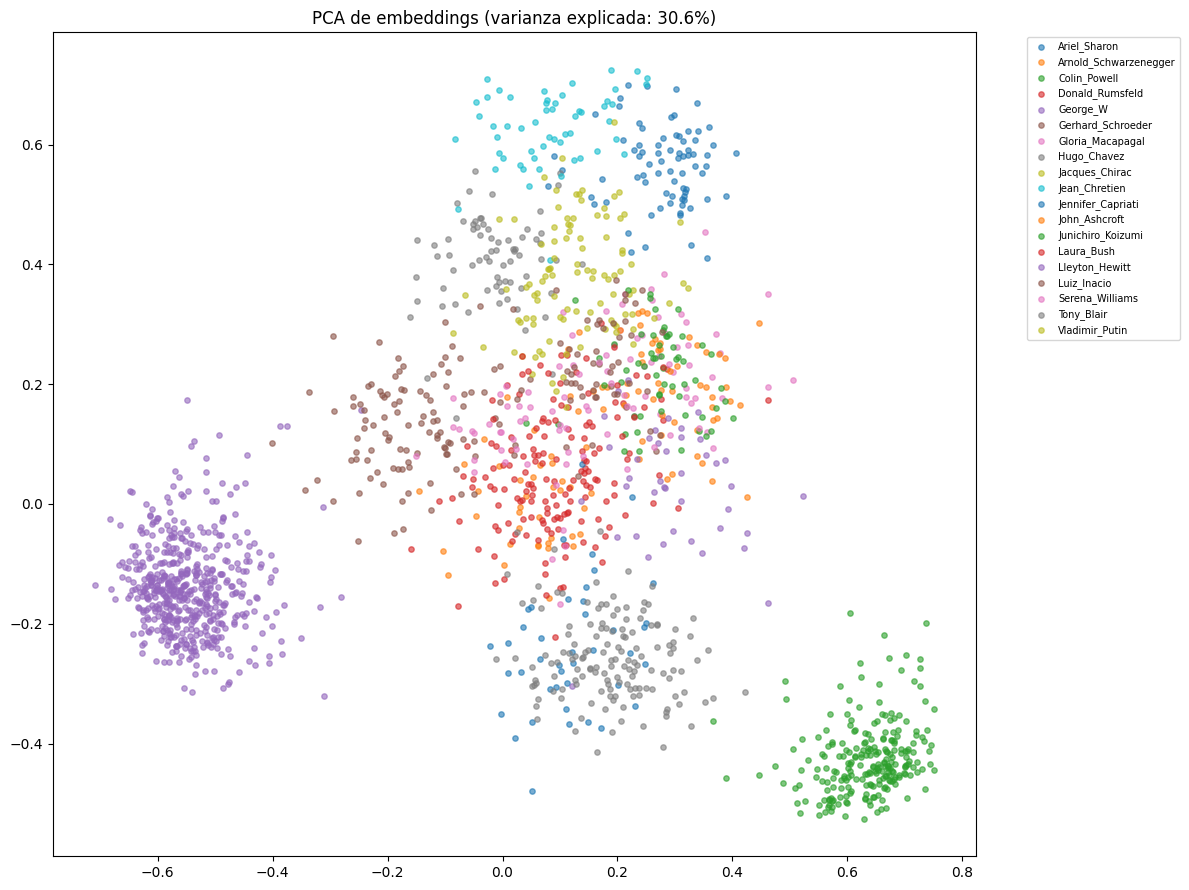

In [17]:
emb_array   = np.array(all_embeddings)
label_array = np.array(all_labels)

pca     = PCA(n_components=2, random_state=42)
emb_pca = pca.fit_transform(emb_array)

fig, ax = plt.subplots(figsize=(12, 9))
for persona in le.classes_:
    mask = label_array == persona
    ax.scatter(emb_pca[mask, 0], emb_pca[mask, 1], label=persona, alpha=0.6, s=15)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
ax.set_title(f'PCA de embeddings (varianza explicada: {pca.explained_variance_ratio_.sum():.1%})')
plt.tight_layout(); plt.show()


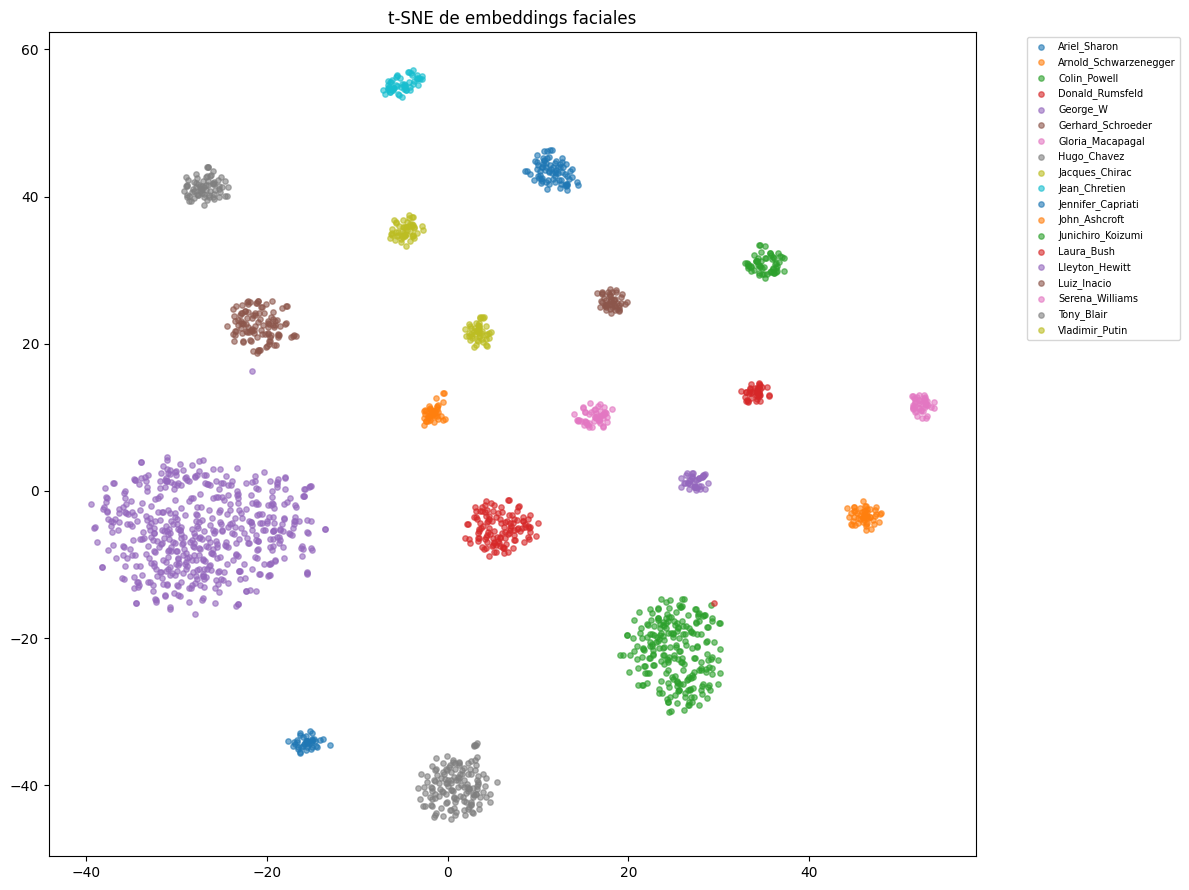

In [19]:
tsne     = TSNE(n_components=2, random_state=42, perplexity=30)
emb_tsne = tsne.fit_transform(emb_array)

fig, ax = plt.subplots(figsize=(12, 9))
for persona in le.classes_:
    mask = label_array == persona
    ax.scatter(emb_tsne[mask, 0], emb_tsne[mask, 1], label=persona, alpha=0.6, s=15)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
ax.set_title('t-SNE de embeddings faciales')
plt.tight_layout(); plt.show()


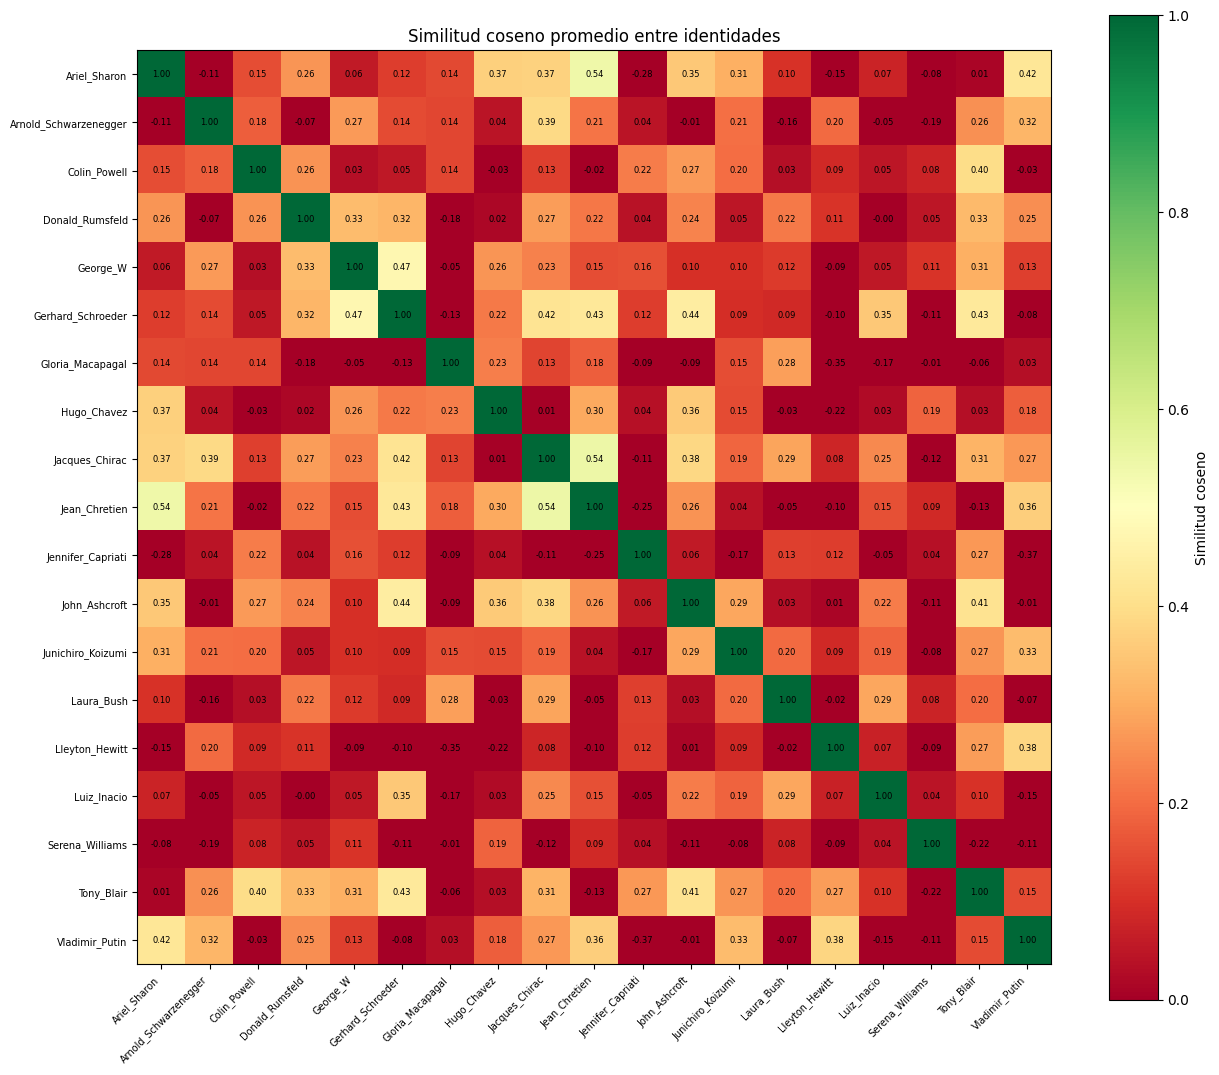

In [20]:
personas_emb = {}
for persona in le.classes_:
    mask = label_array == persona
    personas_emb[persona] = emb_array[mask].mean(axis=0)

nombres  = list(personas_emb.keys())
embs_avg = np.array(list(personas_emb.values()))
norms    = np.linalg.norm(embs_avg, axis=1, keepdims=True)
embs_avg = embs_avg / np.clip(norms, 1e-8, None)
sim_mat  = embs_avg @ embs_avg.T

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(sim_mat, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Similitud coseno')
ax.set_xticks(range(len(nombres))); ax.set_yticks(range(len(nombres)))
ax.set_xticklabels(nombres, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(nombres, fontsize=7)
for i in range(len(nombres)):
    for j in range(len(nombres)):
        ax.text(j, i, f'{sim_mat[i,j]:.2f}', ha='center', va='center', color='black', fontsize=6)
ax.set_title('Similitud coseno promedio entre identidades')
plt.tight_layout(); plt.show()


# Guardado

In [14]:
embeddings_to_save = []
for k, emb in embeddings_db.items():
    persona = "_".join(k.split("_")[:2])
    embeddings_to_save.append({
        "id_imagen": k,
        "embedding": emb.tolist() if hasattr(emb, "tolist") else emb,
        "path": str(output_dir / f"{k}.jpg"),
        "etiqueta": persona,
        "metadata": {"fuente": "LFW", "split": "train"}
    })

with open("src/data/embeddings.json", "w") as f:
    json.dump(embeddings_to_save, f)

print(f" Guardados {len(embeddings_to_save)} embeddings")

 Guardados 1867 embeddings
